In [1]:
#########################
# MLP su FashionMNIST  #
########################

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
# 1. Device (CPU o GPU se disponibile)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [3]:
# 2. Dataset e DataLoader
batch_size = 256

transform = transforms.Compose([
    transforms.ToTensor(),                    # converte in tensor [0,1]
    transforms.Normalize((0.5,), (0.5,)),     # normalizzazione semplice
])

train_dataset = datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

In [4]:
# 3. Definizione del modello (MLP molto semplice)
model = nn.Sequential(
    nn.Flatten(),              # 28x28 -> 784
    nn.Linear(28*28, 256),
    nn.ReLU(),
    nn.Linear(256, 10)         # 10 classi
).to(device)

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=10, bias=True)
)


In [6]:
# 4. Loss e ottimizzatore
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

# 5. Liste per salvare l'andamento
train_losses = []
train_accuracies = []
test_accuracies  = []

In [8]:
# 6. Funzione per calcolare l'accuracy su un dataloader
def accuracy(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total   += y.size(0)

    return correct / total

In [9]:
# 7. Ciclo di training
num_epochs = 10

for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        # forward
        logits = model(X)
        loss = criterion(logits, y)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # accumulo statistiche training
        running_loss += loss.item() * X.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total   += y.size(0)

    # metriche di epoca
    epoch_loss = running_loss / total
    epoch_train_acc = correct / total
    epoch_test_acc  = accuracy(model, test_loader, device)

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_train_acc)
    test_accuracies.append(epoch_test_acc)

    print(
        f"Epoca {epoch:02d} | "
        f"Loss train: {epoch_loss:.4f} | "
        f"Acc train: {epoch_train_acc:.4f} | "
        f"Acc test: {epoch_test_acc:.4f}"
    )

Epoca 01 | Loss train: 0.6649 | Acc train: 0.7653 | Acc test: 0.7856
Epoca 02 | Loss train: 0.4725 | Acc train: 0.8307 | Acc test: 0.8079
Epoca 03 | Loss train: 0.4211 | Acc train: 0.8482 | Acc test: 0.8296
Epoca 04 | Loss train: 0.3925 | Acc train: 0.8580 | Acc test: 0.8352
Epoca 05 | Loss train: 0.3747 | Acc train: 0.8651 | Acc test: 0.8393
Epoca 06 | Loss train: 0.3572 | Acc train: 0.8710 | Acc test: 0.8324
Epoca 07 | Loss train: 0.3450 | Acc train: 0.8758 | Acc test: 0.8554
Epoca 08 | Loss train: 0.3341 | Acc train: 0.8793 | Acc test: 0.8627
Epoca 09 | Loss train: 0.3227 | Acc train: 0.8825 | Acc test: 0.7948
Epoca 10 | Loss train: 0.3167 | Acc train: 0.8859 | Acc test: 0.8588


<function matplotlib.pyplot.show(close=None, block=None)>

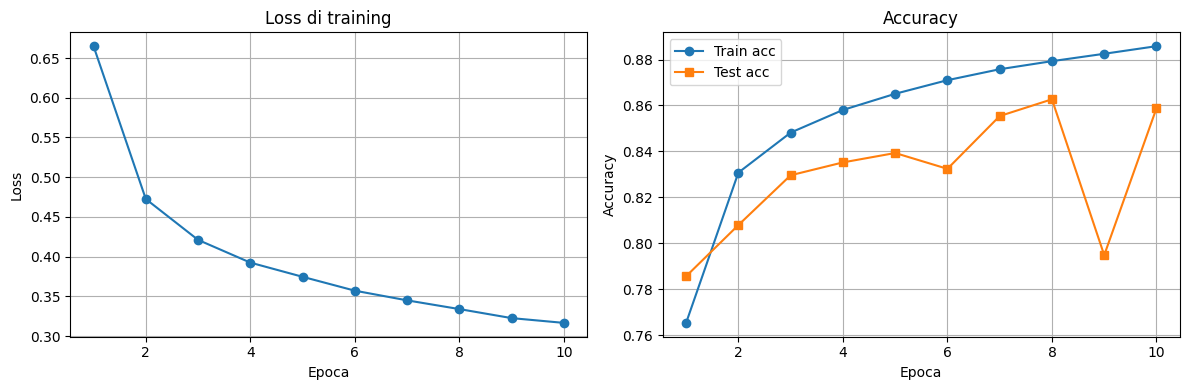

In [10]:
# 8. Plot dell'andamento (Loss e Accuracy)
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12,4))

# Plot loss
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, marker='o')
plt.title("Loss di training")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.grid(True)

# Plot accuracy
plt.subplot(1,2,2)
plt.plot(epochs, train_accuracies, marker='o', label="Train acc")
plt.plot(epochs, test_accuracies,  marker='s', label="Test acc")
plt.title("Accuracy")
plt.xlabel("Epoca")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show